Week3_Assignment

In [54]:
import pandas as pd
import numpy as np

In [55]:
#Q1.
df = pd.read_csv("agriculture_yield_dataset.csv")
print(df.head(10))

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat     Sandy            

In [56]:
print("Number of rows and columns in dataset:",df.shape)

Number of rows and columns in dataset: (1500, 8)


In [57]:
print("Column names:", df.columns)

Column names: Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


In [58]:
#Q2.
print("Datatypes of each column:\n",df.dtypes)

Datatypes of each column:
 rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [59]:
df.info() #to identify the missing values present in any column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   object 
 6   soil_type              1500 non-null   object 
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), object(2)
memory usage: 93.9+ KB


In [60]:
#Q3.Summary statistics for numerical features
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [61]:
#highest mean value is of the rainfall_mm column
#highest standard deviation is of the rainfall_mm column.

In [62]:
!pip install plotly matplotlib seaborn --quiet

In [63]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [64]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']="#00000000"

In [65]:
#Q4.
fig = px.histogram(df,
                   x='rainfall_mm',
                   marginal='box',
                   nbins=47,
                   title='Distribution of rainfall')
fig.update_layout(bargap=0.1)
fig.show()

In [66]:
fig = px.histogram(df,
                   x='temperature_c',
                   marginal='box',
                   nbins=47,
                   title='Variation of temperature in C')
fig.update_layout(bargap=0.1)
fig.show()

In [67]:
fig = px.histogram(df,
                   x='fertilizer_kg',
                   marginal='box',
                   nbins=47,
                   title='Distribution for use of fertilizer in Kg')
fig.update_layout(bargap=0.1)
fig.show()

In [68]:
fig = px.histogram(df,
                   x='yield_ton_per_hectare',
                   marginal='box',
                   nbins=47,
                   title='Yield obtained per hectares in tons')
fig.update_layout(bargap=0.1)
fig.show()

In [69]:
#Q5.
df.crop_type.value_counts()

,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


In [70]:
px.histogram(df,x='crop_type',title='Types of crops')

In [71]:
#Q6.
df.soil_type.value_counts()

,count
soil_type,
Clay,534
Sandy,492
Loamy,474


In [72]:
px.histogram(df,x='soil_type',title='Types of soil')

In [73]:
#Q7.
fig = px.histogram(df,
                   x='yield_ton_per_hectare',
                   marginal='box',
                   nbins=47,
                   title='Yield obtained per hectares in tons')
fig.update_layout(bargap=0.1)
fig.show()

In [74]:
#Q8.
fig=px.scatter(df,
               x='rainfall_mm',
               y='yield_ton_per_hectare',
               color='soil_type',
               opacity=0.8,
               hover_data=['yield_ton_per_hectare'],
               title="Rainfall vs. Yield")
fig.update_traces(marker_size=5)
fig.show()

In [75]:
fig=px.scatter(df,
               x='fertilizer_kg',
               y='yield_ton_per_hectare',
               color='soil_type',
               opacity=0.8,
               hover_data=['yield_ton_per_hectare'],
               title="Fertilizer use vs. Yield")
fig.update_traces(marker_size=5)
fig.show()

In [76]:
avg_crop=df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(avg_crop)
avg_soil=df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(avg_soil)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [77]:
#Q9.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['crop_type']=le.fit_transform(df['crop_type'])
df['soil_type']=le.fit_transform(df['soil_type'])

In [78]:
df.corr()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.039569,-0.007904,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,0.041556,-0.008634,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.027912,0.018753,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,-0.008147,-0.046006,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,-0.000765,-0.035217,0.024412
crop_type,0.039569,0.041556,0.027912,-0.008147,-0.000765,1.000000,0.002310,0.154771
soil_type,-0.007904,-0.008634,0.018753,-0.046006,-0.035217,0.002310,1.000000,-0.227301
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,0.154771,-0.227301,1.000000


Text(0.5, 1.0, 'Correlation matrix')

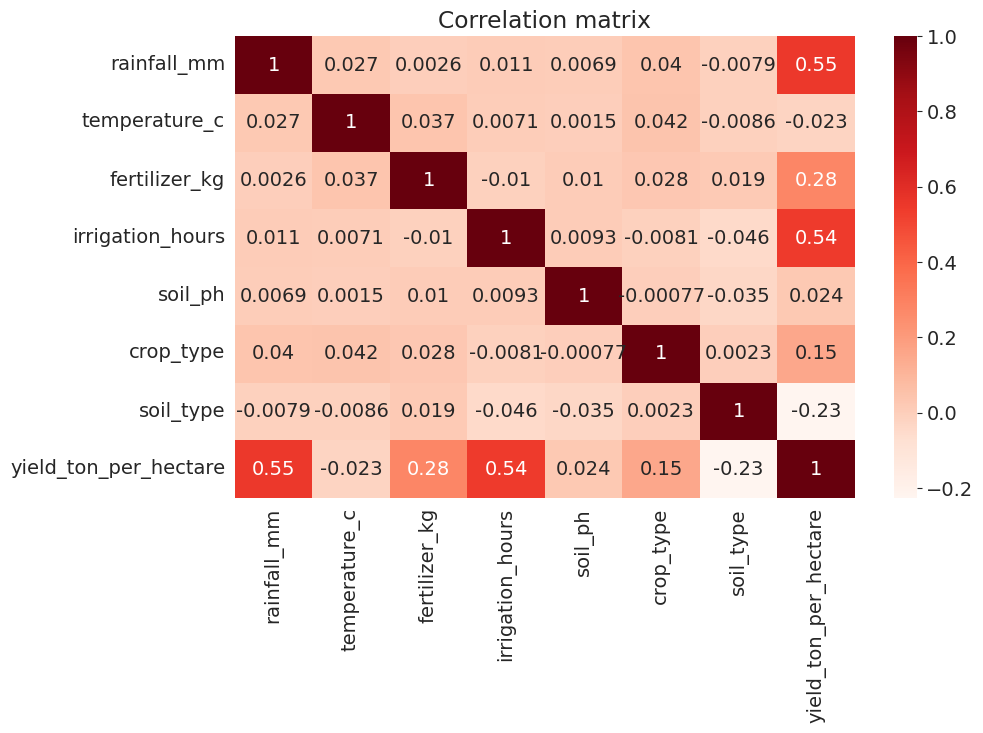

In [79]:
sns.heatmap(df.corr(),cmap='Reds',annot=True)
plt.title("Correlation matrix")

In [80]:
#Q10.
avg_crop=df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(avg_crop)
avg_soil=df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(avg_soil)

crop_type
0    4.607299
1    4.897143
2    5.494744
3    5.173431
4    4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
0    5.134326
1    5.366519
2    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [81]:
#Q11.
df_encoded= pd.get_dummies(df,
                           columns=['crop_type',
                                    'soil_type'],
                           drop_first=True)
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_1,crop_type_2,crop_type_3,crop_type_4,soil_type_1,soil_type_2
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [82]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   yield_ton_per_hectare  1500 non-null   float64
 6   crop_type_1            1500 non-null   bool   
 7   crop_type_2            1500 non-null   bool   
 8   crop_type_3            1500 non-null   bool   
 9   crop_type_4            1500 non-null   bool   
 10  soil_type_1            1500 non-null   bool   
 11  soil_type_2            1500 non-null   bool   
dtypes: bool(6), float64(6)
memory usage: 79.2 KB


In [93]:
#Q12.
target='yield_ton_per_hectare'
x = df_encoded.drop(columns=['yield_ton_per_hectare'])
y = df_encoded['yield_ton_per_hectare']
print("Input features:\n",x.head())
print("Target variable:\n",y.head())

Input features:
    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_1  crop_type_2  crop_type_3  crop_type_4  soil_type_1  \
0         True        False        False        False         True   
1         True        False        False        False        False   
2        False        False        False         True        False   
3         True        False        False        False         True   
4        False        False        False        False        False   

   soil_type_2  
0        False  
1         True  
2         True  
3        False  
4        False  
Target va

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [96]:
#Q13.
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [97]:
print("Shape:\n")
print("x_train:",x_train.shape)
print("y_train:",y_train.shape)
print("x_test",x_test.shape)
print("y_test",y_test)

Shape:

x_train: (1200, 11)
y_train: (1200,)
x_test (300, 11)
y_test 1116    3.80
1368    5.76
422     3.48
413     4.34
451     4.26
        ... 
983     4.79
799     4.63
1265    6.93
1150    6.29
824     4.26
Name: yield_ton_per_hectare, Length: 300, dtype: float64


In [ ]:
#Q14. Linear Regression model